# Notebook 08 — Distance Scaling: Train & Compare

Trains the LSTM and Transformer decoders at d=3, d=5, and d=7.  
The central question: **do neural decoders scale with distance like MWPM does?**

Key difference from previous notebooks — the model input size changes with d:
```
d=3 : LSTM input (N, 9,  8)   Transformer input (N, 9,  8)
d=5 : LSTM input (N, 9, 24)   Transformer input (N, 9, 24)
d=7 : LSTM input (N, 9, 48)   Transformer input (N, 9, 48)
```
The Transformer scales better here — attention cost is O(rounds²) which is fixed,
while the LSTM hidden state must grow to handle more stabilisers per round.

**Prerequisite:** Run notebook 07 first.
```bash
pip install torch scikit-learn numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import os, time, warnings
warnings.filterwarnings('ignore')

SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DISTANCES  = [3, 5, 7]
ROUNDS     = 9
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Distance-Aware Model Definitions

In [2]:
def stabilisers_for_distance(d):
    """Number of stabilisers per round = d²-1 for rotated surface code."""
    return d**2 - 1


class LSTMDecoder(nn.Module):
    """LSTM scaled for arbitrary stabiliser count."""
    def __init__(self, input_size, lstm_hidden=None, lstm_layers=2,
                 dense=None, dropout=0.2):
        super().__init__()
        # Scale hidden size with input — larger codes need more capacity
        if lstm_hidden is None:
            lstm_hidden = max(36, input_size * 4)
        if dense is None:
            dense = [lstm_hidden * 2, lstm_hidden, lstm_hidden // 2]

        self.lstm = nn.LSTM(input_size, lstm_hidden, lstm_layers,
                            batch_first=True,
                            dropout=dropout if lstm_layers > 1 else 0.0)
        layers, in_d = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_d, h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.head = nn.Sequential(*layers)
        self.lstm_hidden = lstm_hidden
        self.dense_dims  = dense

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)


class SyndromeTransformer(nn.Module):
    """Transformer scaled for arbitrary stabiliser count."""
    def __init__(self, input_size, num_rounds=9, d_model=64, nhead=4,
                 num_layers=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed  = nn.Embedding(num_rounds, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1))

    def forward(self, x):
        tok = self.input_proj(x)
        pos = torch.arange(x.shape[1], device=x.device)
        tok = tok + self.pos_embed(pos).unsqueeze(0)
        enc = self.transformer(tok)
        return self.head(enc.mean(dim=1)).squeeze(-1)


# Preview parameter counts at each distance
print(f"  {'d':>4}  {'Stabs':>6}  {'LSTM params':>12}  {'Transformer params':>20}")
print("-" * 50)
for d in DISTANCES:
    s = stabilisers_for_distance(d)
    lstm_p = sum(p.numel() for p in LSTMDecoder(s).parameters())
    tr_p   = sum(p.numel() for p in SyndromeTransformer(s).parameters())
    print(f"  d={d}  {s:>6}  {lstm_p:>12,}  {tr_p:>20,}")

     d   Stabs   LSTM params    Transformer params
--------------------------------------------------
  d=3       8        23,257                70,209
  d=5      24       163,201                71,233
  d=7      48       648,961                72,769


---
## 2. Training Loop

In [3]:
def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

@torch.no_grad()
def predict(model, X, batch_size=1024):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE))) > 0.5).cpu().numpy())
    return np.concatenate(out)


def train(model, X_tr, y_tr, X_val, y_val, label="",
          epochs=120, lr=1e-3, patience=15):
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=6, factor=0.5)
    pw    = torch.tensor([(1-y_tr.mean())/max(y_tr.mean(), 1e-6)]).to(DEVICE)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pw)
    tr_l  = make_loader(X_tr, y_tr)
    va_l  = make_loader(X_val, y_val, shuffle=False)
    best_vl, best_ep, best_st = np.inf, 0, None
    t0 = time.time()

    for ep in range(1, epochs+1):
        model.train()
        tc, tt = 0, 0
        for Xb, yb in tr_l:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tc += ((torch.sigmoid(model(Xb))>0.5).float()==yb).sum().item()
            tt += len(yb)
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in va_l:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                vl += crit(logits, yb).item()*len(yb)
                vc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
                vt += len(yb)
        vl /= vt; sch.step(vl)
        if vl < best_vl:
            best_vl = vl; best_ep = ep
            best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 30 == 0:
            print(f"  [{label}] Ep {ep:3d}  val_LER={(1-vc/vt):.5f}")
        if ep - best_ep >= patience:
            print(f"  [{label}] Early stop ep={ep} (best={best_ep})")
            break

    model.load_state_dict(best_st)
    print(f"  [{label}] Done {time.time()-t0:.0f}s")
    return model

print("Training utilities defined.")

Training utilities defined.


---
## 3. Train at Each Distance

In [4]:
results = {}   # d → {lstm_ler, tr_ler, lstm_sweep, tr_sweep}

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

for d in DISTANCES:
    print(f"\n{'='*60}")
    print(f"Distance d={d}  (stabilisers/round = {stabilisers_for_distance(d)})")
    print('='*60)

    stabs = stabilisers_for_distance(d)

    # Load training data
    det = np.load(f"data/d{d}/detection_events.npy").astype(np.float32)
    obs = np.load(f"data/d{d}/observable_flips.npy").astype(np.float32).squeeze()

    # Reshape for sequence models
    det_seq = det.reshape(-1, ROUNDS, stabs)

    # Split
    idx = np.arange(len(obs))
    idx_tr, idx_tmp = train_test_split(idx, test_size=0.30,
                                        stratify=obs.astype(int), random_state=SEED)
    idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                        stratify=obs[idx_tmp].astype(int), random_state=SEED)

    seq_tr  = det_seq[idx_tr];  obs_tr  = obs[idx_tr]
    seq_val = det_seq[idx_val]; obs_val = obs[idx_val]
    seq_te  = det_seq[idx_te];  obs_te  = obs[idx_te]
    trivial = obs_te.mean()

    print(f"  LER: {trivial:.4f}  |  seq shape: {det_seq.shape}")

    # ── Train LSTM ────────────────────────────────────────────────────────────
    print(f"\n  Training LSTM (d={d})...")
    lstm = LSTMDecoder(stabs).to(DEVICE)
    lstm = train(lstm, seq_tr, obs_tr, seq_val, obs_val, label=f"LSTM-d{d}")
    pred_lstm = predict(lstm, seq_te)
    ler_lstm  = float((pred_lstm != obs_te).mean())
    print(f"  LSTM Test LER: {ler_lstm:.5f}  ({trivial/ler_lstm:.1f}x)")

    # ── Train Transformer ─────────────────────────────────────────────────────
    print(f"\n  Training Transformer (d={d})...")
    transformer = SyndromeTransformer(stabs).to(DEVICE)
    transformer = train(transformer, seq_tr, obs_tr, seq_val, obs_val,
                        label=f"TR-d{d}")
    pred_tr = predict(transformer, seq_te)
    ler_tr  = float((pred_tr != obs_te).mean())
    print(f"  Transformer Test LER: {ler_tr:.5f}  ({trivial/ler_tr:.1f}x)")

    # ── Noise sweep ───────────────────────────────────────────────────────────
    lstm_sweep, tr_sweep = [], []
    for p in NOISE_LEVELS:
        tag   = f"{int(p*10000):04d}"
        det_s = np.load(f"data/d{d}/sweep/det_p{tag}.npy").astype(np.float32)
        obs_s = np.load(f"data/d{d}/sweep/obs_p{tag}.npy").astype(np.float32).squeeze()
        seq_s = det_s.reshape(-1, ROUNDS, stabs)
        lstm_ler_s = float((predict(lstm, seq_s) != obs_s).mean())
        tr_ler_s   = float((predict(transformer, seq_s) != obs_s).mean())
        lstm_sweep.append((p, lstm_ler_s))
        tr_sweep.append((p, tr_ler_s))

    # Save
    torch.save({'model_state': lstm.state_dict(), 'test_ler': ler_lstm,
                'distance': d, 'stabs': stabs}, f"models/lstm_d{d}.pt")
    torch.save({'model_state': transformer.state_dict(), 'test_ler': ler_tr,
                'distance': d, 'stabs': stabs}, f"models/transformer_d{d}.pt")
    np.save(f"results/lstm_d{d}_sweep.npy", np.array(lstm_sweep))
    np.save(f"results/transformer_d{d}_sweep.npy", np.array(tr_sweep))

    results[d] = {
        'trivial':    trivial,
        'lstm_ler':   ler_lstm,
        'tr_ler':     ler_tr,
        'lstm_sweep': lstm_sweep,
        'tr_sweep':   tr_sweep,
    }

print("\nAll distances trained.")


Distance d=3  (stabilisers/round = 8)
  LER: 0.0531  |  seq shape: (100000, 9, 8)

  Training LSTM (d=3)...
  [LSTM-d3] Ep  30  val_LER=0.01727
  [LSTM-d3] Ep  60  val_LER=0.00740
  [LSTM-d3] Early stop ep=69 (best=54)
  [LSTM-d3] Done 78s
  LSTM Test LER: 0.00667  (8.0x)

  Training Transformer (d=3)...
  [TR-d3] Ep  30  val_LER=0.01367
  [TR-d3] Early stop ep=50 (best=35)
  [TR-d3] Done 83s
  Transformer Test LER: 0.01293  (4.1x)

Distance d=5  (stabilisers/round = 24)
  LER: 0.0929  |  seq shape: (100000, 9, 24)

  Training LSTM (d=5)...
  [LSTM-d5] Ep  30  val_LER=0.01673
  [LSTM-d5] Early stop ep=39 (best=24)
  [LSTM-d5] Done 51s
  LSTM Test LER: 0.01653  (5.6x)

  Training Transformer (d=5)...
  [TR-d5] Ep  30  val_LER=0.02387
  [TR-d5] Early stop ep=51 (best=36)
  [TR-d5] Done 89s
  Transformer Test LER: 0.02227  (4.2x)

Distance d=7  (stabilisers/round = 48)
  LER: 0.1273  |  seq shape: (100000, 9, 48)

  Training LSTM (d=7)...
  [LSTM-d7] Ep  30  val_LER=0.01860
  [LSTM-d7] E

---
## 4. Distance Scaling Plot — The Key Figure

The most important figure in this notebook.  
Lines that drop more steeply with increasing d show better scaling.

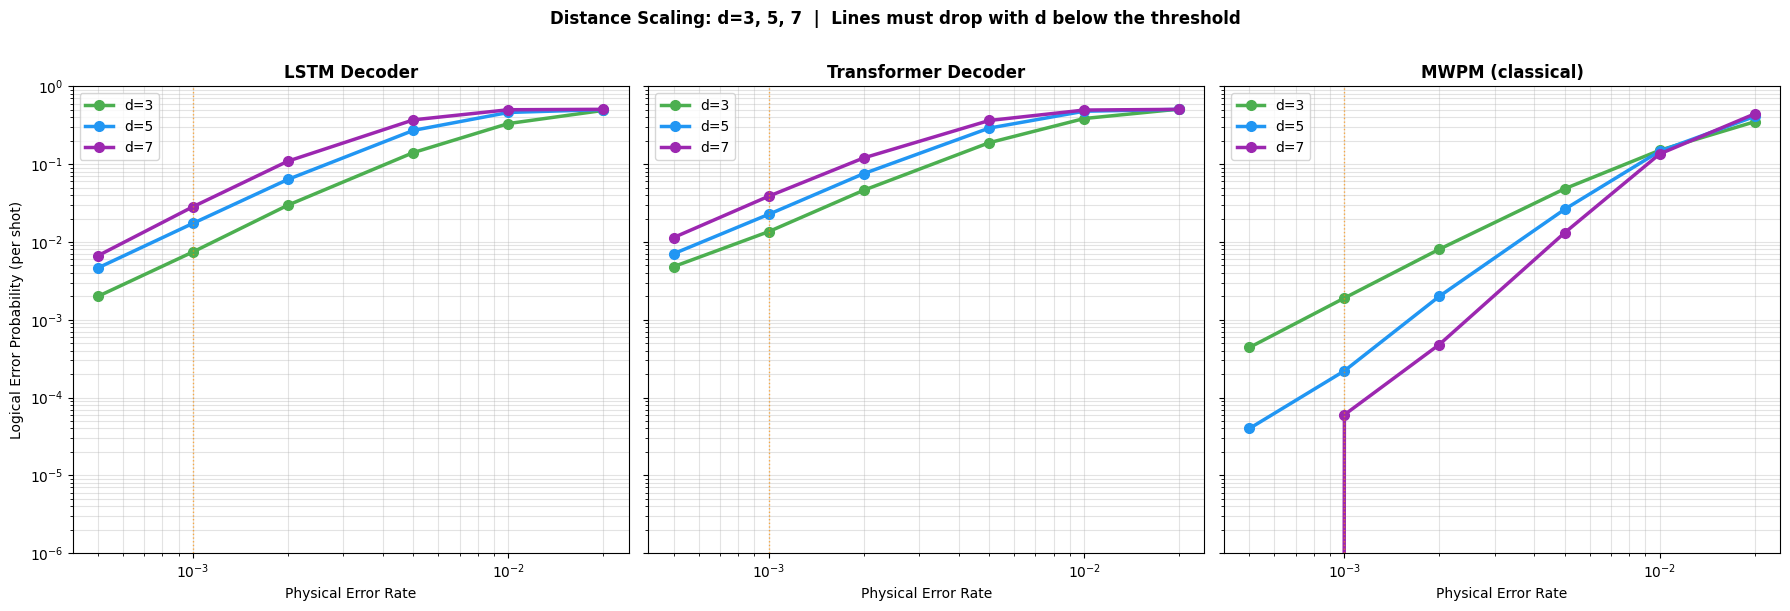

Saved → figures/08_distance_scaling.png


In [5]:
colors_d = {3: '#4CAF50', 5: '#2196F3', 7: '#9C27B0'}
ps = np.array(NOISE_LEVELS)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
titles = ['LSTM Decoder', 'Transformer Decoder', 'MWPM (classical)']

for ax, title in zip(axes, titles):
    for d in DISTANCES:
        if title == 'LSTM Decoder':
            lers = [r[1] for r in results[d]['lstm_sweep']]
        elif title == 'Transformer Decoder':
            lers = [r[1] for r in results[d]['tr_sweep']]
        else:
            try:
                mw = np.load(f"results/mwpm_d{d}_sweep.npy")
                lers = list(mw[:, 1])
            except FileNotFoundError:
                continue

        ax.plot(ps, lers, 'o-', color=colors_d[d],
                lw=2.5, ms=7, label=f'd={d}')

    ax.loglog()
    ax.set_ylim(1e-6, 1)
    ax.grid(which='both', alpha=0.35)
    ax.set_xlabel('Physical Error Rate')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10)
    ax.axvline(x=0.001, color='#FF8F00', lw=1, ls=':', alpha=0.7)

axes[0].set_ylabel('Logical Error Probability (per shot)')
plt.suptitle('Distance Scaling: d=3, 5, 7  |  Lines must drop with d below the threshold',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig('figures/08_distance_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/08_distance_scaling.png")

---
## 5. Summary Table

In [6]:
print("=" * 70)
print("Distance Scaling Results  (p=0.001, 15,000 test shots per distance)")
print("=" * 70)
print(f"  {'d':>4}  {'Trivial':>10}  {'LSTM':>10}  {'LSTM×':>7}  {'Transformer':>12}  {'TR×':>7}")
print("  " + "-"*58)

for d in DISTANCES:
    r = results[d]
    t = r['trivial']
    print(f"  d={d}  {100*t:>8.4f}%  "
          f"{100*r['lstm_ler']:>8.4f}%  "
          f"{t/r['lstm_ler']:>5.1f}x  "
          f"{100*r['tr_ler']:>10.4f}%  "
          f"{t/r['tr_ler']:>5.1f}x")

print()
print("Key: For NN decoders to be useful, LER must DECREASE as d increases.")
print("     If LER increases with d, the decoder is not scaling correctly.")

Distance Scaling Results  (p=0.001, 15,000 test shots per distance)
     d     Trivial        LSTM    LSTM×   Transformer      TR×
  ----------------------------------------------------------
  d=3    5.3067%    0.6667%    8.0x      1.2933%    4.1x
  d=5    9.2933%    1.6533%    5.6x      2.2267%    4.2x
  d=7   12.7267%    2.8533%    4.5x      3.6600%    3.5x

Key: For NN decoders to be useful, LER must DECREASE as d increases.
     If LER increases with d, the decoder is not scaling correctly.
